# Lab 6.01 - Regression analysis

In [1]:
# Package imports
import numpy as np                                  # "Scientific computing"
import scipy.stats as stats                         # Statistical tests

import pandas as pd                                 # Dataframe
import matplotlib.pyplot as plt                     # Basic visualisation
from statsmodels.graphics.mosaicplot import mosaic  # Mosaic plot
import seaborn as sns                               # Advanced dataviz
from sklearn.linear_model import LinearRegression

## Exercise 1: Relation between heart weight and body weight in Cats

### Part 1

Perform a linear regression analysis on the variables body weight (`Bwt`, dependent variable) and heart weight (`Hwt`, independent variabele).


1. Import the dataset `Cats.csv`.


In [2]:
cats = pd.read_csv('https://raw.githubusercontent.com/HoGentTIN/dsai-labs/main/data/Cats.csv')
# Show the first few records of the Data Frame
cats.head()

,ID,Sex,Hwt,Bwt
0,1,F,2.0,7.0
1,2,F,2.0,7.4
2,3,F,2.0,9.5
3,4,F,2.1,7.2
4,5,F,2.1,7.3


2. Draw a scatter plot of both variables.


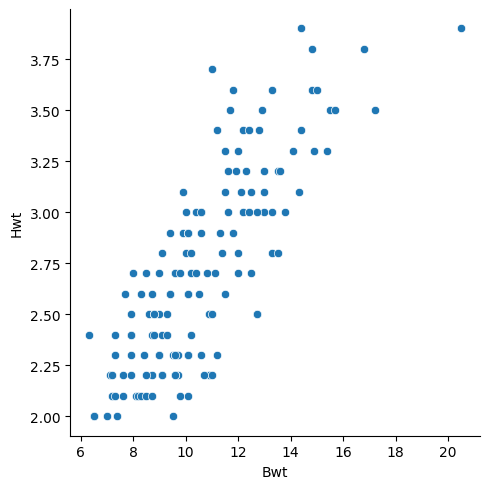

In [ ]:
sns.relplot(data=cats, x='Hwt', y='Bwt')

3. Calculate and draw the regression line.


In [21]:
slope, intercept = np.polyfit(cats['Hwt'], cats['Bwt'], deg=1)
print(f'Slope = {slope}, intercept = {intercept}')
print(f'y = {intercept} + {slope} * x')

Slope = 4.031757486783179, intercept = -0.3510783771969617
y = -0.3510783771969617 + 4.031757486783179 * x


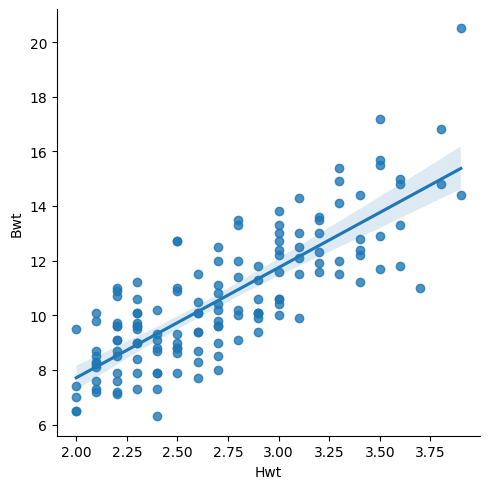

In [27]:

ax = sns.lmplot(data=cats, x='Hwt', y='Bwt')

4. Calculate the correlation coefficient and the coefficient of determination.

In [28]:
r = np.corrcoef(x=cats['Hwt'], y=cats['Bwt'])[0][1]
r2 = r**2

print(f'R = {r}\nR2 = {r2}')

R = 0.804134787315513
R2 = 0.6466327561709654


5. Interpret the results from the previous steps.

In [32]:
print('R > 0 dus het is een stijgend verband.')
print('R is ongeveer 0.8, dit betekent dat er een sterk verband is.')
print(f'64% van de variantie van het gewicht van het lichaam van de kat, valt te verklaren door de relatie met het gewicht van het hart. Er is een sterke en stijgende corelatie.')

R > 0 dus het is een stijgend verband.
R is ongeveer 0.8, dit betekent dat er een sterk verband is.
64% van de variantie van het gewicht van het lichaam van de kat, valt te verklaren door de relatie met het gewicht van het hart. Er is een sterke en stijgende corelatie.


### Part 2

1. Perform a linear regression analysis on the variables body weight (`Bwt`) and heart weight (`Hwt`), but this time **subdivided by gender** (`Sex`). Use the same dataset (`Cats.csv`).


In [33]:
cats = pd.read_csv('https://raw.githubusercontent.com/HoGentTIN/dsai-labs/main/data/Cats.csv')
# Show the first few records of the Data Frame
cats.head()

,ID,Sex,Hwt,Bwt
0,1,F,2.0,7.0
1,2,F,2.0,7.4
2,3,F,2.0,9.5
3,4,F,2.1,7.2
4,5,F,2.1,7.3


2. Draw a scatter plot of both variables for each gender.


<Axes: xlabel='Hwt', ylabel='Bwt'>

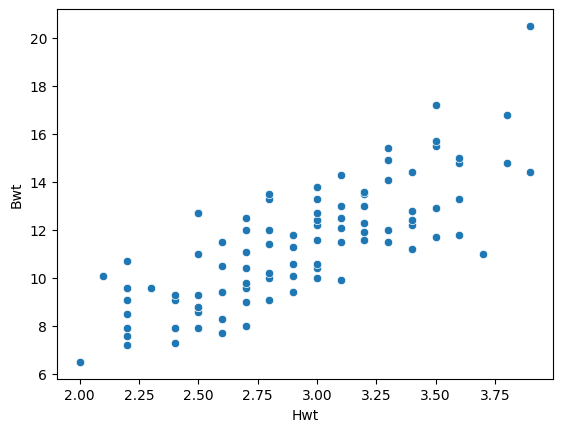

In [37]:
male_cats = cats[(cats['Sex'] == 'M')]
female_cats = cats[(cats['Sex'] == 'F')]

sns.scatterplot(data=male_cats, x='Hwt', y='Bwt')


<Axes: xlabel='Hwt', ylabel='Bwt'>

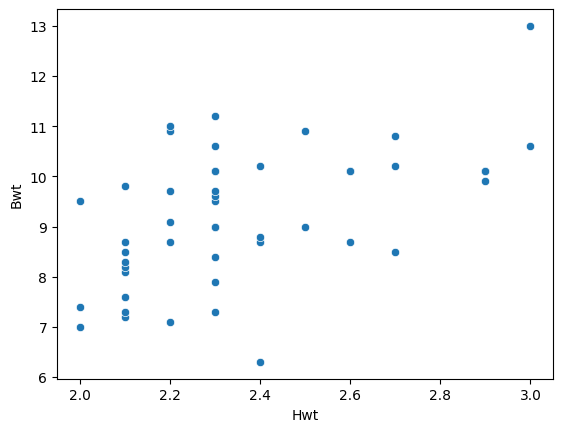

In [38]:
sns.scatterplot(data=female_cats, x='Hwt', y='Bwt')


3. Calculate and draw the regression line.


Regression line for male cats: y = -1.176825253309489 + 4.309818875119161 * x


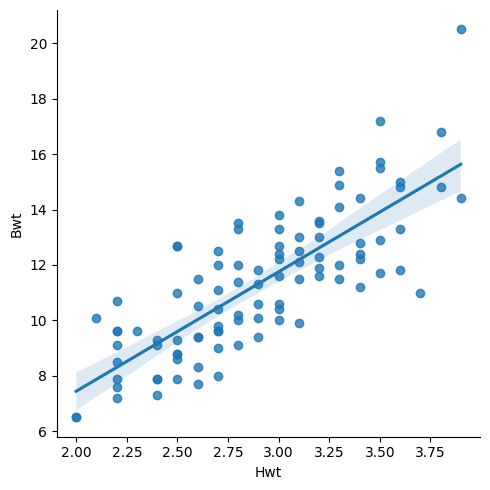

In [41]:
b1, b0 = np.polyfit(x=male_cats['Hwt'], y=male_cats['Bwt'], deg=1)
print(f'Regression line for male cats: y = {b0} + {b1} * x')
sns.lmplot(data=male_cats, x='Hwt', y='Bwt')

Regression line for female cats: y = 2.981312384473199 + 2.6364140480591503 * x


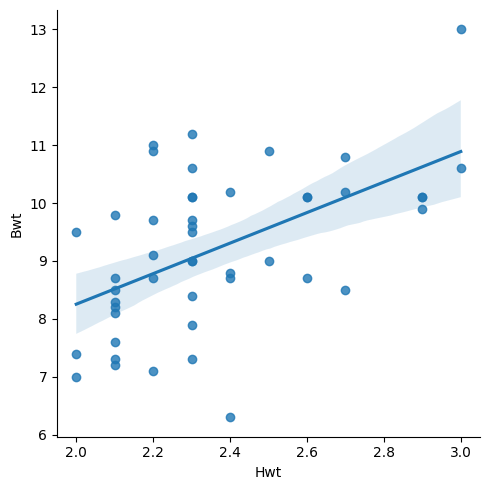

In [42]:
b1, b0 = np.polyfit(x=female_cats['Hwt'], y=female_cats['Bwt'], deg=1)
print(f'Regression line for female cats: y = {b0} + {b1} * x')
sns.lmplot(data=female_cats, x='Hwt', y='Bwt')

4. Calculate the correlation coefficient and the coefficient of determination.


In [43]:
male_r = np.corrcoef(x=male_cats['Hwt'], y=male_cats['Bwt'])[0][1]
female_r = np.corrcoef(x=female_cats['Hwt'], y=female_cats['Bwt'])[0][1]

male_r2 = male_r ** 2
female_r2 = female_r ** 2

print(f'Male cats:\n\tR = {male_r}\n\tR2 = {male_r2}')
print(f'Female cats:\n\tR = {female_r}\n\tR2 = {female_r2}')

Male cats:
	R = 0.7930443171812304
	R2 = 0.628919289013444
Female cats:
	R = 0.5320496665060397
	R2 = 0.28307684762918806


5. Interpret the results from the previous steps.

For male cats R > 0, which indicates an increasing relation. R is also around 0.79 which indicates a strong relationship. Since R2 = 0.62 we can conclude that 62% of the variance in observations is explained by the relation between the two variables.

For female cats R > 0, which indicates an increasing relation. R is around 0.53 which indicates a moderate relationship. Since R2 = 0.28 we can conclude that 28% of the variance in observations is explained by the relation between the two variables.

### Answers

| Selection |  $\beta_0$ | $\beta_1$ |       $R$ |     $R^2$ |
| :-------- | ---------: | --------: | --------: | --------: |
| All       | -0.3510784 | 4.0317575 | 0.8041348 | 0.6466328 |
| Male      | -1.1768253 | 4.3098189 | 0.7930443 | 0.6289193 |
| Female    |  2.9813124 |  2.636414 | 0.5320497 | 0.2830768 |
